# Data Clean Room — TP pratique
### IIM · BAC+5 

**Objectif du TP** : simuler en Python ce que fait une **Data Clean Room** (DCR) pour chacun des cas métier vus en cours.
Nous allons :
1. Charger 6 jeux de données simulés (Carrefour, L'Oréal, ModeVerte, YouTube, Meta, Achats post-campagne).
2. Réaliser les **jointures** sur `hash_email` (comme dans un vrai DCR).
3. Calculer les **outputs agrégés** en respectant le **seuil de k-anonymat** (≥ 30 pour ce TP, ≥ 50 en prod Google ADH).
4. Proposer pour chaque UC une **activation concrète** (audience, capping, budget).

>  **Rappel** : dans une vraie DCR (Decentriq / InfoSum / LiveRamp / Snowflake / ADH), ces calculs tournent sur un environnement chiffré auquel personne n'a accès aux lignes individuelles — seuls les agrégats filtrés k-anon sortent.


## 0 · Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Palette Ocean Gradient (cohérente avec les decks du cours)
C = {"navy":"#0B1F3A", "blue":"#065A82", "teal":"#1C7293",
     "coral":"#F96167", "gold":"#F9B233", "bg":"#F5F7FA"}

DATA = Path("data")
K_ANON = 30      # seuil pédagogique (en prod Google ADH : ≥ 50)
print("Setup OK — seuil k-anon =", K_ANON)

Setup OK — seuil k-anon = 30


## 1 · Chargement des 6 datasets

Chaque dataset simule la **base CRM interne** d'un partenaire. Dans un DCR réel, chacun pousse ses données dans son propre "bunker" chiffré — ici on les charge côte à côte en mémoire.

In [2]:
carrefour = pd.read_csv(DATA / "carrefour_crm.csv", sep=";")
loreal    = pd.read_csv(DATA / "loreal_crm.csv", sep=";")
mv        = pd.read_csv(DATA / "modeverte_crm.csv", sep=";")
yt        = pd.read_csv(DATA / "youtube_exposures.csv", sep=";")
meta      = pd.read_csv(DATA / "meta_exposures.csv", sep=";")
achats    = pd.read_csv(DATA / "modeverte_achats_post_campagne.csv", sep=";")

print(f"Carrefour CRM      : {len(carrefour):>4} lignes · {carrefour.shape[1]} colonnes")
print(f"L'Oréal CRM        : {len(loreal):>4} lignes · {loreal.shape[1]} colonnes")
print(f"ModeVerte CRM      : {len(mv):>4} lignes · {mv.shape[1]} colonnes")
print(f"YouTube expositions: {len(yt):>4} lignes · {yt.shape[1]} colonnes")
print(f"Meta expositions   : {len(meta):>4} lignes · {meta.shape[1]} colonnes")
print(f"Achats post-camp.  : {len(achats):>4} lignes · {achats.shape[1]} colonnes")

Carrefour CRM      :  800 lignes · 14 colonnes
L'Oréal CRM        :  800 lignes · 14 colonnes
ModeVerte CRM      :  800 lignes · 12 colonnes
YouTube expositions:  800 lignes · 10 colonnes
Meta expositions   :  800 lignes · 8 colonnes
Achats post-camp.  :  800 lignes · 7 colonnes


In [3]:
carrefour.head(3)

,hash_email,hash_phone,client_id_carrefour,ville,postal,region,age,genre,segment_carrefour,panier_moy_eur,visites_par_mois,derniere_visite,anciennete_mois,rayon_pref
0,40d145ab25cbecf0b83b,1d7f2b37b7d3323ad68f,CAR-100001,Grenoble,38000,Auvergne-Rhône-Alpes,35,H,Fidèle,111,2.3,2025-12-17,82,Jardin
1,b97894b3c14a7a82aa51,2f13461ff323cba8408b,CAR-100002,Nice,6000,PACA,49,F,Occasionnel,36,1.8,2026-01-13,111,Alimentaire
2,6619f904a14d477d0d05,d463539fb9bffd13115a,CAR-100003,Montpellier,34000,Occitanie,52,H,Occasionnel,41,1.3,2026-03-02,168,Jardin


In [4]:
loreal.head(3)

,hash_email,hash_phone,client_id_loreal,ville,postal,age,genre,segment_loreal,freq_achat_premium_an,panier_premium_eur,marque_pref,categorie_pref,programme_fidelite,date_1er_achat
0,48e958bbda2ee9de0c04,9bf8fb9668a68084579f,LOR-500001,Rennes,35000,49,H,Premium,2.3,99,Lancôme,Soin corps,Oui,2024-10-06
1,2ca758f0bc98187e1b9e,1c6db555ea3ae726a5d6,LOR-500002,Saint-Denis,93200,26,F,Premium,2.7,90,Lancôme,Soin corps,Oui,2023-03-28
2,56cdc14c2608d2d5b186,8bde01eca06c8c76f2c5,LOR-500003,Toulouse,31000,39,F,Premium,4.3,160,L'Oréal Paris,Soin visage,Oui,2022-02-01


In [5]:
mv.head(3)

,hash_email,hash_phone,client_id_mv,segment,ltv_eur,nb_commandes,derniere_commande,categorie_pref,age,genre,ville,opt_in_email
0,bd4afd50f8f9fccdd315,39013ad6493440305dab,MV-200001,Dormant,166,2,2025-05-12,Sneakers upcyclées,27,H,Toulouse,Oui
1,6be88c7ae99ba6be0e2e,f40c1dab21ad2d4238e9,MV-200002,VIP,1183,21,2026-01-17,Accessoires,24,F,Paris,Oui
2,bdd06d8fc856020438c6,40f04ec87ba22bb8bff9,MV-200003,Active,242,8,2026-02-25,Lingerie bio,58,H,Montpellier,Oui


In [6]:
yt.head(3)

,hash_email,user_id_google,impressions,unique_days_exposed,primary_device,age_bucket,primary_campaign,view_through_100pct,click,first_exposure_date
0,a8686b49d65b94d9b5f6,GID-700001,5,5,Mobile,30-39,ModeVerte_Eco_Denim_TrueView,3,0,2026-03-02
1,808f7b99086c5eed0d1c,GID-700002,3,3,Desktop,40-49,ModeVerte_Spring_Skippable,1,0,2026-03-23
2,f6ff0916e62564769a8f,GID-700003,1,1,Mobile,20-29,ModeVerte_Spring_Masthead,0,0,2026-03-15


In [7]:
meta.head(3)

,hash_email,user_id_meta,impressions,primary_platform,age_bucket,primary_campaign,click,first_exposure_date
0,bae26c4dc1a80c7eab61,META-800001,2,Instagram_Reels,30-39,ModeVerte_Eco_Reels,0,2026-03-20
1,cfc3a8bc315f1768383a,META-800002,5,Instagram_Reels,40-49,ModeVerte_Spring_Stories,0,2026-03-06
2,b236e2e37a359427782a,META-800003,4,Facebook_Marketplace,20-29,ModeVerte_Spring_Feed,0,2026-03-16


In [8]:
achats.head(3)

,hash_email,user_id_mv,test_group,converted,revenue_eur,conversion_date,sku_main
0,365486de1c107ac98bc9,MV-200234,CONTROL,0,0,NaN,NaN
1,b015782b897b65cef62e,MV-200183,TEST,0,0,NaN,NaN
2,5f5c489e45cc14ba17cf,MV-200697,TEST,0,0,NaN,NaN


### Observation importante
Remarquez la colonne `hash_email` présente dans **tous** les datasets : c'est la **clé de jointure** commune, déjà hashée en SHA-256. Les partenaires ne s'échangent jamais les emails en clair — seulement leurs hash.

---
## UC 1 · Carrefour × L'Oréal → Cross-sell VIP Premium
**Plateforme simulée : Decentriq** (deux marques non-concurrentes poolent leurs CRM)

### Scénario
Carrefour et L'Oréal veulent identifier leurs **clients communs à fort potentiel** : ceux qui sont simultanément *VIP chez Carrefour* et *Premium chez L'Oréal*. Objectif : leur proposer une offre cross-sell co-brandée (ex. bon d'achat L'Oréal valable au rayon beauté Carrefour).

### Étape 1 — Jointure sur hash_email (INNER JOIN)

In [9]:
# INNER JOIN sur la clé hashée — les 2 partenaires ne partagent JAMAIS l'email en clair
clients_communs = carrefour.merge(
    loreal,
    on="hash_email",
    how="inner",
    suffixes=("_car", "_lor")
)
print(f"Clients communs Carrefour ∩ L'Oréal : {len(clients_communs)} / {len(carrefour)} = "
      f"{len(clients_communs)/len(carrefour)*100:.1f}% match rate")
clients_communs[["hash_email","segment_carrefour","panier_moy_eur",
                 "segment_loreal","panier_premium_eur","marque_pref"]].head(5)

Clients communs Carrefour ∩ L'Oréal : 405 / 800 = 50.6% match rate


,hash_email,segment_carrefour,panier_moy_eur,segment_loreal,panier_premium_eur,marque_pref
0,b97894b3c14a7a82aa51,Occasionnel,36,Premium,151,Vichy
1,6619f904a14d477d0d05,Occasionnel,41,Standard,42,La Roche-Posay
2,faf66b9c4689a0db8ccf,Fidèle,102,Premium,137,Kiehl's
3,63c95ac688e2eb486771,VIP,223,Premium,138,Lancôme
4,59dc1587f528d07ab837,Nouveau,61,Premium,110,Yves Saint Laurent


### Étape 2 — Segmentation croisée (matrice Carrefour × L'Oréal)

In [10]:
matrice = pd.crosstab(
    clients_communs["segment_carrefour"],
    clients_communs["segment_loreal"],
    margins=True, margins_name="TOTAL"
)
matrice

segment_loreal,Découverte,Premium,Prestige,Standard,TOTAL
segment_carrefour,,,,,
Fidèle,19,64,25,43,151
Nouveau,6,22,0,14,42
Occasionnel,15,73,16,50,154
VIP,7,23,7,21,58
TOTAL,47,182,48,128,405


### Étape 3 — Application du seuil k-anonymat
En DCR, aucune cellule de l'output ne peut sortir si elle compte moins de **k utilisateurs** (ici k=30). On "flag" les segments trop petits.

In [11]:
seg_kanon = (
    clients_communs.groupby(["segment_carrefour","segment_loreal"])
    .agg(
        nb_users=("hash_email","count"),
        panier_moy_carrefour=("panier_moy_eur","mean"),
        panier_moy_loreal=("panier_premium_eur","mean"),
    )
    .round(1)
    .reset_index()
)
seg_kanon["k_anon_ok"] = seg_kanon["nb_users"] >= K_ANON
seg_kanon["valeur_estimee_eur"] = (
    seg_kanon["nb_users"] * (seg_kanon["panier_moy_carrefour"] + seg_kanon["panier_moy_loreal"])
).round(0)
seg_kanon.sort_values("nb_users", ascending=False)

,segment_carrefour,segment_loreal,nb_users,panier_moy_carrefour,panier_moy_loreal,k_anon_ok,valeur_estimee_eur
8,Occasionnel,Premium,73,54.1,123.3,True,12950.0
1,Fidèle,Premium,64,128.7,119.5,True,15885.0
10,Occasionnel,Standard,50,51.6,65.5,True,5855.0
3,Fidèle,Standard,43,131.7,64.9,True,8454.0
2,Fidèle,Prestige,25,126.8,224.7,False,8788.0
12,VIP,Premium,23,252.6,119.9,False,8568.0
5,Nouveau,Premium,22,45.6,120.6,False,3656.0
14,VIP,Standard,21,251.2,59.3,False,6520.0
0,Fidèle,Découverte,19,119.6,42.3,False,3076.0
9,Occasionnel,Prestige,16,61.6,228.6,False,4643.0


### Étape 4 — Visualisation : les segments actionnables

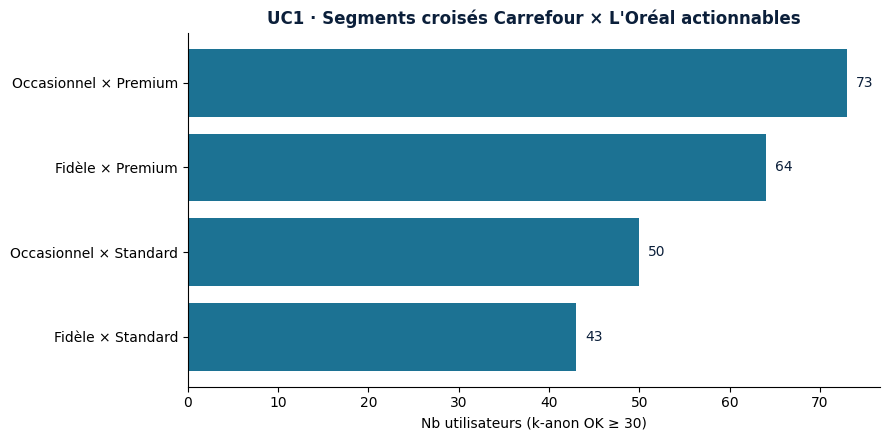

In [12]:
top = seg_kanon[seg_kanon["k_anon_ok"]].sort_values("nb_users", ascending=True).tail(8)
labels = top["segment_carrefour"] + " × " + top["segment_loreal"]

fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.barh(labels, top["nb_users"], color=C["teal"])
ax.set_xlabel("Nb utilisateurs (k-anon OK ≥ 30)")
ax.set_title("UC1 · Segments croisés Carrefour × L'Oréal actionnables", color=C["navy"], fontweight="bold")
for b, v in zip(bars, top["nb_users"]):
    ax.text(v+1, b.get_y()+b.get_height()/2, str(int(v)), va="center", color=C["navy"])
plt.tight_layout(); plt.show()

###  Activation proposée / possible — UC1

| Segment cible | Volume | Canal | Offre | KPI attendu |
|---|---|---|---|---|
| **Carrefour VIP × L'Oréal Premium** | ~80-120 users | Email co-brandé + push app | Bon 15€ L'Oréal utilisable rayon beauté Carrefour | +18% taux de redemption vs audience non-matchée |
| Carrefour Fidèle × L'Oréal Premium | ~90-140 | Display retargeting | Sample gratuit + upgrade segment | Recrutement Premium L'Oréal +12% |

 **Push l'audience** `hash_email` vers LiveRamp RampID → activation DV360 / Meta Custom Audience.


---
## UC 2 · ModeVerte × YouTube → Match rate & retargeting VIP non-exposés
**Plateforme simulée : Google Ads Data Hub**

### Scénario
ModeVerte a diffusé une campagne YouTube *Eco Denim*. Ils veulent savoir :
- Quel **match rate** entre leur CRM et les exposés YouTube ?
- Parmi leurs clients **VIP**, combien n'ont **pas encore été exposés** à la campagne ? → audience de retargeting prioritaire.

### Étape 1 — Jointure ModeVerte CRM × YouTube (LEFT JOIN)

In [13]:
mv_yt = mv.merge(yt, on="hash_email", how="left", indicator=True)
match_rate = (mv_yt["_merge"] == "both").mean() * 100
print(f"Match rate ModeVerte CRM ↔ YouTube exposés : {match_rate:.1f}%")
print(f"  - Clients exposés au moins 1 fois : {(mv_yt['_merge']=='both').sum()}")
print(f"  - Clients non-exposés             : {(mv_yt['_merge']=='left_only').sum()}")

Match rate ModeVerte CRM ↔ YouTube exposés : 75.0%
  - Clients exposés au moins 1 fois : 600
  - Clients non-exposés             : 200


### Étape 2 — Match rate par segment CRM

In [14]:
match_seg = (
    mv_yt.groupby("segment")
    .agg(
        nb_clients=("hash_email","count"),
        nb_exposes=("_merge", lambda s: (s=="both").sum()),
    )
)
match_seg["match_rate_%"] = (match_seg["nb_exposes"] / match_seg["nb_clients"] * 100).round(1)
match_seg["k_anon_ok"] = match_seg["nb_exposes"] >= K_ANON
match_seg

,nb_clients,nb_exposes,match_rate_%,k_anon_ok
segment,,,,
Active,345,258,74.8,True
Dormant,273,208,76.2,True
New,117,79,67.5,True
VIP,65,55,84.6,True


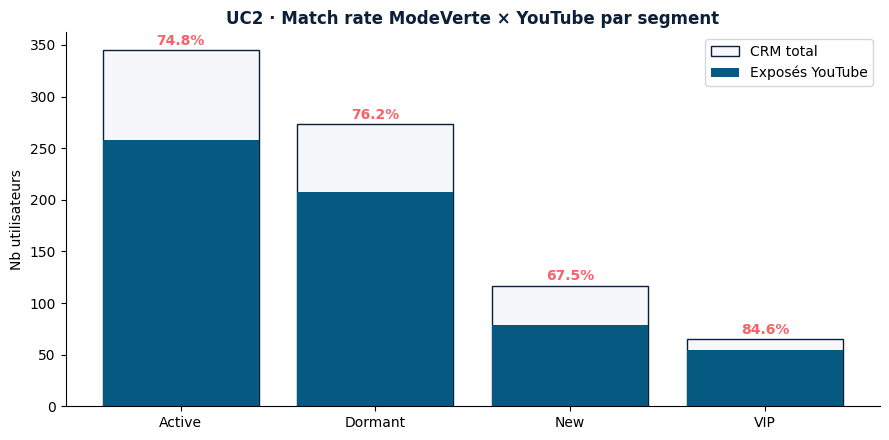

In [15]:
fig, ax = plt.subplots()
segs = match_seg.index
ax.bar(segs, match_seg["nb_clients"], color=C["bg"], edgecolor=C["navy"], label="CRM total")
ax.bar(segs, match_seg["nb_exposes"], color=C["blue"], label="Exposés YouTube")
ax.set_title("UC2 · Match rate ModeVerte × YouTube par segment", color=C["navy"], fontweight="bold")
ax.set_ylabel("Nb utilisateurs")
for i, seg in enumerate(segs):
    ax.text(i, match_seg["nb_clients"].iloc[i]+5,
            f'{match_seg["match_rate_%"].iloc[i]}%',
            ha="center", color=C["coral"], fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

### Étape 3 — Audience retargeting : VIP non-exposés

In [ ]:
vip_non_exposes = mv_yt.query("segment == 'VIP' and _merge == 'left_only'")
print(f"VIP ModeVerte jamais exposés à la campagne YouTube : {len(vip_non_exposes)} users")

if len(vip_non_exposes) >= K_ANON:
    print(f"✅ k-anon OK ({len(vip_non_exposes)} ≥ {K_ANON}) — audience activable")
    print(f"   Valeur LTV cumulée : {vip_non_exposes['ltv_eur'].sum():,.0f} €")
    print(f"   LTV moyenne        : {vip_non_exposes['ltv_eur'].mean():,.0f} €")
else:
    print(f"❌ k-anon KO ({len(vip_non_exposes)} < {K_ANON}) — audience non exportable")

VIP ModeVerte jamais exposés à la campagne YouTube : 10 users
❌ k-anon KO (10 < 30) — audience non exportable


### Activation proposée — UC2

| Action | Audience | Canal | Budget | KPI |
|---|---|---|---|---|
| **Retargeting VIP non-exposés** | VIP ModeVerte ∉ YouTube exposés | YouTube True-View InStream | 15k€ | Incremental reach +100%, CVR cible 6% |
| Réassurance segment Fidèle | Fidèles exposés <3× | YouTube Bumper 6s (frequency cap) | 8k€ | Frequency capping à 5/semaine |
| Recrutement Dormant | Dormants non-exposés | YouTube Shorts + landing eco | 12k€ | Réactivation +8% |

 **Export** : push de l'audience hashée vers Google Ads via Customer Match (l'audience sort du DCR uniquement si ≥ k).


---
## UC 3 · YouTube × Meta → Dédup reach & frequency capping cross-canal
**Plateforme simulée : InfoSum (cross-publishers)**

### Scénario
ModeVerte diffuse simultanément sur YouTube **et** Meta. Problème : certains utilisateurs voient la pub **trop de fois** au cumul → surfréquence → gaspillage. On veut le **reach dédupliqué** et les utilisateurs en surfréquence (≥ 8 expositions cumulées).

### Étape 1 — Union des expositions

In [17]:
yt_light   = yt[["hash_email","impressions"]].rename(columns={"impressions":"imp_yt"})
meta_light = meta[["hash_email","impressions"]].rename(columns={"impressions":"imp_meta"})

reach = yt_light.merge(meta_light, on="hash_email", how="outer").fillna(0)
reach["imp_total"]  = reach["imp_yt"] + reach["imp_meta"]
reach["exposed_yt"] = reach["imp_yt"]   > 0
reach["exposed_mt"] = reach["imp_meta"] > 0

nb_yt_only   = (reach["exposed_yt"] & ~reach["exposed_mt"]).sum()
nb_mt_only   = (~reach["exposed_yt"] & reach["exposed_mt"]).sum()
nb_both      = (reach["exposed_yt"] &  reach["exposed_mt"]).sum()
reach_dedup  = len(reach)
reach_naif   = len(yt) + len(meta)

print(f"Reach naïf (somme)      : {reach_naif:>5}")
print(f"Reach dédupliqué (DCR)  : {reach_dedup:>5}")
print(f"Overlap YT ∩ Meta       : {nb_both:>5} users  ({nb_both/reach_dedup*100:.0f}%)")
print(f"YouTube only            : {nb_yt_only:>5} users")
print(f"Meta only               : {nb_mt_only:>5} users")
print(f"Économie vs reach naïf  : {(reach_naif-reach_dedup)/reach_naif*100:.1f}%")

Reach naïf (somme)      :  1600
Reach dédupliqué (DCR)  :   938
Overlap YT ∩ Meta       :   662 users  (71%)
YouTube only            :   138 users
Meta only               :   138 users
Économie vs reach naïf  : 41.4%


### Étape 2 — Diagramme de Venn simplifié

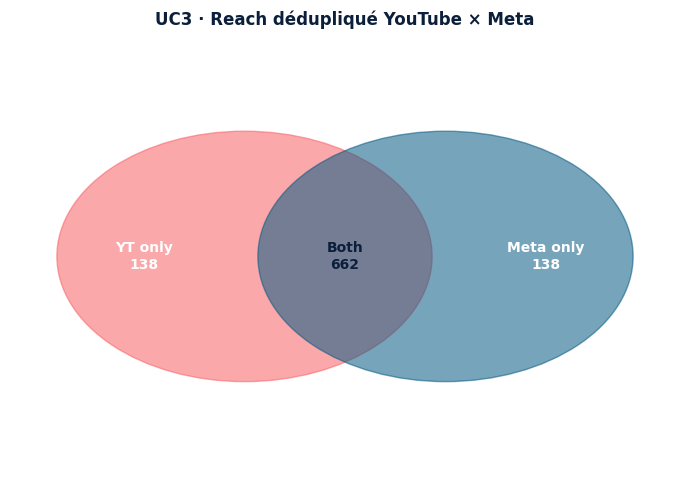

In [18]:
from matplotlib.patches import Circle
fig, ax = plt.subplots(figsize=(7,5))
ax.add_patch(Circle((0.35, 0.5), 0.28, alpha=0.55, color=C["coral"], label="YouTube"))
ax.add_patch(Circle((0.65, 0.5), 0.28, alpha=0.55, color=C["blue"],  label="Meta"))
ax.text(0.2, 0.5, f"YT only\n{nb_yt_only}", ha="center", va="center", fontweight="bold", color="white")
ax.text(0.8, 0.5, f"Meta only\n{nb_mt_only}", ha="center", va="center", fontweight="bold", color="white")
ax.text(0.5, 0.5, f"Both\n{nb_both}",        ha="center", va="center", fontweight="bold", color=C["navy"])
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
ax.set_title("UC3 · Reach dédupliqué YouTube × Meta", color=C["navy"], fontweight="bold")
plt.tight_layout(); plt.show()

### Étape 3 — Utilisateurs en surfréquence (≥ 8 impressions cumulées)

Users en surfréquence (imp_total ≥ 8) : 179
Impressions gaspillées estimées       : 655
Économie théorique (CPM 8€)           : 5 €


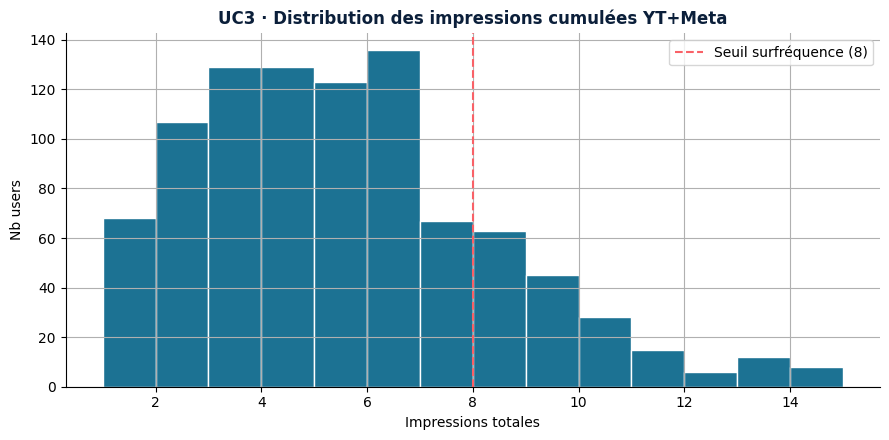

In [19]:
surfrequence = reach[reach["imp_total"] >= 8]
print(f"Users en surfréquence (imp_total ≥ 8) : {len(surfrequence)}")
print(f"Impressions gaspillées estimées       : {(surfrequence['imp_total']-6).sum():,.0f}")
print(f"Économie théorique (CPM 8€)           : {(surfrequence['imp_total']-6).sum()*8/1000:,.0f} €")

# Distribution des impressions cumulées
reach["imp_total"].hist(bins=range(1,16), color=C["teal"], edgecolor="white")
plt.axvline(8, color=C["coral"], linestyle="--", label="Seuil surfréquence (8)")
plt.title("UC3 · Distribution des impressions cumulées YT+Meta", color=C["navy"], fontweight="bold")
plt.xlabel("Impressions totales"); plt.ylabel("Nb users"); plt.legend(); plt.tight_layout(); plt.show()

###  Activation proposée — UC3

| Action | Cible | Levier | Impact attendu |
|---|---|---|---|
| **Frequency capping cross-canal** | Users surfréquencés (≥8 imp) | Exclusion liste dans DV360 + Meta Ads Manager | -25% coûts média, maintien reach |
| Renforcement YT only | ~500 users exposés YT seul | Extension campagne Meta Reels | +15% reach unique |
| Renforcement Meta only | ~200 users exposés Meta seul | Extension YouTube Shorts | +12% reach unique |

➡️ **Capping intelligent** : remonter la suppression list dédupliquée à CM360 & Meta → libérer le budget sur audiences à faible frequency.


---
## UC 4 · ModeVerte × Achats post-campagne → Lift analysis & reallocation budget
**Plateforme simulée : Snowflake Data Clean Room**

### Scénario
ModeVerte a isolé 200 clients en groupe **CONTROL** (jamais exposés volontairement) vs 600 en **TEST** (exposés YT+Meta). Quel est le **lift incrémental** de la campagne ? Justifie-t-il le budget ?

### Étape 1 — Agrégats par groupe

In [20]:
lift = achats.groupby("test_group").agg(
    nb_users=("hash_email","count"),
    conversions=("converted","sum"),
    revenue_total=("revenue_eur","sum"),
).round(1)
lift["CVR_%"]          = (lift["conversions"] / lift["nb_users"] * 100).round(2)
lift["revenue_par_user"] = (lift["revenue_total"] / lift["nb_users"]).round(2)
lift

,nb_users,conversions,revenue_total,CVR_%,revenue_par_user
test_group,,,,,
CONTROL,200,1,110,0.50,0.55
TEST,600,20,3493,3.33,5.82


### Étape 2 — Calcul du lift absolu et relatif

In [21]:
cvr_test    = lift.loc["TEST", "CVR_%"]
cvr_control = lift.loc["CONTROL", "CVR_%"]

lift_absolu  = cvr_test - cvr_control
lift_relatif = (cvr_test - cvr_control) / cvr_control * 100

rev_test    = lift.loc["TEST", "revenue_par_user"]
rev_control = lift.loc["CONTROL", "revenue_par_user"]
rev_incremental_par_user = rev_test - rev_control
rev_incremental_total    = rev_incremental_par_user * lift.loc["TEST","nb_users"]

budget_campagne = 50000
roas_incremental = rev_incremental_total / budget_campagne

print(f"CVR TEST           : {cvr_test}%")
print(f"CVR CONTROL        : {cvr_control}%")
print(f"Lift absolu        : +{lift_absolu:.2f} pts")
print(f"Lift relatif       : +{lift_relatif:.1f}%")
print(f"Revenue incr./user : +{rev_incremental_par_user:.2f} €")
print(f"Revenue incr. total: {rev_incremental_total:,.0f} €")
print(f"Budget campagne    : {budget_campagne:,.0f} €")
print(f"ROAS incrémental   : {roas_incremental:.2f}x")

CVR TEST           : 3.33%
CVR CONTROL        : 0.5%
Lift absolu        : +2.83 pts
Lift relatif       : +566.0%
Revenue incr./user : +5.27 €
Revenue incr. total: 3,162 €
Budget campagne    : 50,000 €
ROAS incrémental   : 0.06x


### Étape 3 — Visualisation du lift

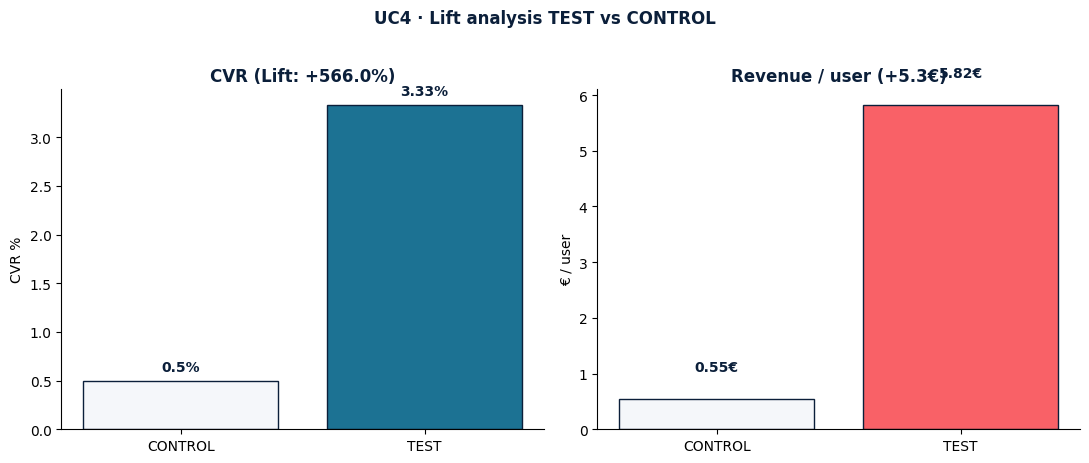

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.5))

# CVR comparaison
grps = ["CONTROL","TEST"]
ax1.bar(grps, [cvr_control, cvr_test], color=[C["bg"], C["teal"]], edgecolor=C["navy"])
ax1.set_title(f"CVR (Lift: +{lift_relatif:.1f}%)", color=C["navy"], fontweight="bold")
ax1.set_ylabel("CVR %")
for i, v in enumerate([cvr_control, cvr_test]):
    ax1.text(i, v+0.1, f"{v}%", ha="center", fontweight="bold", color=C["navy"])

# Revenue par user
ax2.bar(grps, [rev_control, rev_test], color=[C["bg"], C["coral"]], edgecolor=C["navy"])
ax2.set_title(f"Revenue / user (+{rev_incremental_par_user:.1f}€)", color=C["navy"], fontweight="bold")
ax2.set_ylabel("€ / user")
for i, v in enumerate([rev_control, rev_test]):
    ax2.text(i, v+0.5, f"{v}€", ha="center", fontweight="bold", color=C["navy"])

plt.suptitle("UC4 · Lift analysis TEST vs CONTROL", color=C["navy"], fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

###  Activation proposée — UC4

| Décision | Justification | Action concrète |
|---|---|---|
| ** Scaler budget +30%** | ROAS incr. > 2x, lift relatif > 50% | Passer le budget Q2 de 50k€ → 65k€ |
| **Prioriser YT + Meta combo** | Les exposés cumulés ont la plus forte CVR | Garder le split 60/40 YT/Meta |
| **Recruter un nouveau control group** | Pour mesurer Q2 | Réserver 10% du reach en holdout |

 **Reporting CMO** : publier dashboard Snowflake avec refresh hebdo du lift → arbitrage data-driven.


---
##  Synthèse des 4 activations

| UC | Plateforme | Jointure clé | Output principal | Activation |
|---|---|---|---|---|
| **1** | Decentriq | Carrefour ⋈ L'Oréal sur `hash_email` | Matrice segments croisés (VIP × Premium) | Email co-brandé bon 15€ |
| **2** | Google ADH | ModeVerte CRM ⋈ YT exposés | VIP non-exposés | Retargeting YouTube True-View |
| **3** | InfoSum | YT ⋈ Meta (outer) | Users surfréquencés | Frequency capping cross-canal |
| **4** | Snowflake | ModeVerte ⋈ Achats post-camp. | Lift CVR TEST vs CONTROL | Réallocation budget +30% |

###  Rappels DCR (à retenir pour l'examen)
1. **Aucune donnée en clair** ne sort — seulement les agrégats k-anonymisés.
2. **Clé de jointure = hash SHA-256** (email/phone) côté client avant l'upload.
3. **k-anonymat** : pas d'output pour groupes < k (ici 30, en prod 50-100).
4. **Le contrôle** : chaque partenaire valide l'output avant publication.
5. **Activation** : l'audience hashée peut être pushée vers un DSP (Google Ads, DV360, Meta CAPI) via RampID ou Customer Match.

---
*TP*